In [1]:
import os
from pathlib import Path
from typing import Optional, Union, List

import torch
import torchaudio
from efficientnet_pytorch import EfficientNet
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, DistributedSampler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


from kiwano.features import Fbank
from kiwano.augmentation import Augmentation, Noise, Codec, Filtering, Normal, Sometimes, Linear, CMVN, Crop, SpecAugment, Reverb
from kiwano.dataset import Segment, SegmentSet
from kiwano.model import JeffreysLoss, IDRDScheduler

#import EfficientNetV2 from /home/hleguilier/Documents/Thèse/Resnet34/kiwano/kiwano/model/EfficientNet.py
from kiwano.model import EfficientNetV2

/home/hleguilier/anaconda3/envs/speaker-verification/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hleguilier/anaconda3/envs/speaker-verification/lib/python3.9/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/hleguilier

In [2]:
# Chemin des données
data_dir = Path("data/voxceleb1")

# Trouver tous les fichiers .wav
def find_audio_files(directory, extension=".wav"):
    return list(directory.rglob(f"*{extension}"))

audio_files = find_audio_files(data_dir)
print(f"Nombre de fichiers audio trouvés : {len(audio_files)}")

Nombre de fichiers audio trouvés : 153516


In [3]:
class SpeakerTrainingSegmentSet(Dataset, SegmentSet): #divise le corpus en segments pour l'entrainement et applique les transformations audio et features
    def __init__(self, audio_transforms: List[Augmentation] = None, feature_extractor = None, feature_transforms: List[Augmentation] = None):
        super().__init__()
        self.audio_transforms = audio_transforms
        self.feature_transforms = feature_transforms
        self.feature_extractor = feature_extractor

    def __getitem__(self, segment_id_or_index: Union[int, str]) -> Segment:
        segment = None
        if isinstance(segment_id_or_index, str):
            segment = self.segments[segment_id_or_index]
        else:
            try:
                segment = next(val for idx, val in enumerate(self.segments.values()) if idx == segment_id_or_index)
            except StopIteration:
                raise KeyError(f"Index {segment_id_or_index} non trouvé dans segments.")

        audio, sample_rate = segment.load_audio()
        if self.audio_transforms is not None:
            audio, sample_rate = self.audio_transforms(audio, sample_rate)

        if self.feature_extractor is not None:
            feature = self.feature_extractor.extract(audio, sampling_rate=sample_rate)

        if self.feature_transforms is not None:
            feature = self.feature_transforms(feature)

        spkid = segment.spkid
        if spkid not in self.labels:
            print(f"Clé du segment : {segment_id_or_index}, spkid : {spkid}")
            print(f"Labels disponibles : {list(self.labels.keys())[:10]}")
            raise KeyError(f"Clé manquante dans labels : {spkid}")

        return feature, self.labels[spkid]



In [4]:
musan = SegmentSet()
musan.from_dict(Path("data/musan"))

musan_music = musan.get_speaker("music")
musan_speech = musan.get_speaker("speech")
musan_noise = musan.get_speaker("noise")

reverb = SegmentSet()
reverb.from_dict(Path("data/rirs_noises"))


In [5]:
# Chargement des données d'entraînement
training_data = SpeakerTrainingSegmentSet(
    audio_transforms=Sometimes([
        Noise(musan_music, snr_range=[5, 15]),
        Noise(musan_speech, snr_range=[13, 20]),
        Noise(musan_noise, snr_range=[0, 15]),
        Normal(),
        Reverb(reverb),
    ]),
    feature_extractor=Fbank(),
    feature_transforms=Linear([
        CMVN(),
        Crop(350),
        SpecAugment(),
    ]),
)

In [6]:
# Charger le corpus VoxCeleb1
training_data.from_dict(data_dir)

In [7]:
"""# Vérifier les attributs de l'objet training_data
print("Attributs de training_data :", dir(training_data))

# Afficher les types des principaux champs attendus
if hasattr(training_data, "segments"):
    print("\nType de training_data.segments :", type(training_data.segments))
    print("Nombre de segments :", len(training_data.segments))

    # Exemple de clés et d'éléments
    print("\nExemple de clé dans segments :", next(iter(training_data.segments.keys())))
    print("Exemple de valeur dans segments :", training_data.segments[next(iter(training_data.segments.keys()))])

if hasattr(training_data, "labels"):
    print("\nType de training_data.labels :", type(training_data.labels))
    print("Nombre de labels :", len(training_data.labels))

    # Exemple de clés et d'éléments
    print("\nExemple de clé dans labels :", next(iter(training_data.labels.keys())))
    print("Exemple de valeur dans labels :", training_data.labels[next(iter(training_data.labels.keys()))])"""


Attributs de training_data : ['__add__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_is_protocol', 'append', 'audio_transforms', 'combine', 'copy', 'describe', 'display', 'feature_extractor', 'feature_transforms', 'from_dict', 'get_labels', 'get_random', 'get_speaker', 'labels', 'load_audio', 'perturb_speed', 'segments', 'truncate']

Type de training_data.segments : <class 'dict'>
Nombre de segments : 153516

Exemple de clé dans segments : id10111_pLHg7KbMZds_00019
Exemple de valeur dans segments : <kiwano.dataset.base.Segment object at 0x75d5d71f0400>

Type de training_data.labels :

In [8]:
# Diviser les segments en un ensemble d'entraînement et de validation
all_segments = list(training_data.segments.keys())
train_segments, val_segments = train_test_split(
    all_segments,
    test_size=0.2,  # 20% pour la validation
    random_state=42
)

In [9]:
# Créer le dataset d'entraînement
train_data = SpeakerTrainingSegmentSet(
    audio_transforms=training_data.audio_transforms,
    feature_extractor=training_data.feature_extractor,
    feature_transforms=training_data.feature_transforms
)
train_data.segments = {key: training_data.segments[key] for key in train_segments}

# Reconstruire les labels en utilisant les spkid comme clés
train_data.labels = {segment.spkid: training_data.labels[segment.spkid] for segment in train_data.segments.values()}


In [10]:
# Créer le dataset de validation
val_data = SpeakerTrainingSegmentSet(
    audio_transforms=None,  # Pas d'augmentation sur le set de validation
    feature_extractor=training_data.feature_extractor,
    feature_transforms=training_data.feature_transforms
)
val_data.segments = {key: training_data.segments[key] for key in val_segments}

# Reconstruire les labels pour la validation en utilisant les spkid comme clés
val_data.labels = {segment.spkid: training_data.labels[segment.spkid] for segment in val_data.segments.values()}

In [21]:
# Créer le DataLoader
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

In [25]:
"""print(f"Nombre de segments pour l'entraînement : {len(train_data.segments)}")
print(f"Nombre de segments pour la validation : {len(val_data.segments)}")

# Exemple de segment et de label
key = next(iter(train_data.segments.keys()))
print(f"Exemple de segment : {key}")
print(f"Exemple de label : {train_data.labels[train_data.segments[key].spkid]}")"""


Nombre de segments pour l'entraînement : 122812
Nombre de segments pour la validation : 30704
Exemple de segment : id10750_3oqzMfP3xTU_00003
Exemple de label : 221


Train Dataset:
Spectrogram Type: <class 'torch.Tensor'>, Shape: torch.Size([350, 81])
Spectrogram Type: <class 'torch.Tensor'>, Shape: torch.Size([350, 81])
Spectrogram Type: <class 'torch.Tensor'>, Shape: torch.Size([350, 81])
Spectrogram Type: <class 'torch.Tensor'>, Shape: torch.Size([350, 81])
Spectrogram Type: <class 'torch.Tensor'>, Shape: torch.Size([350, 81])


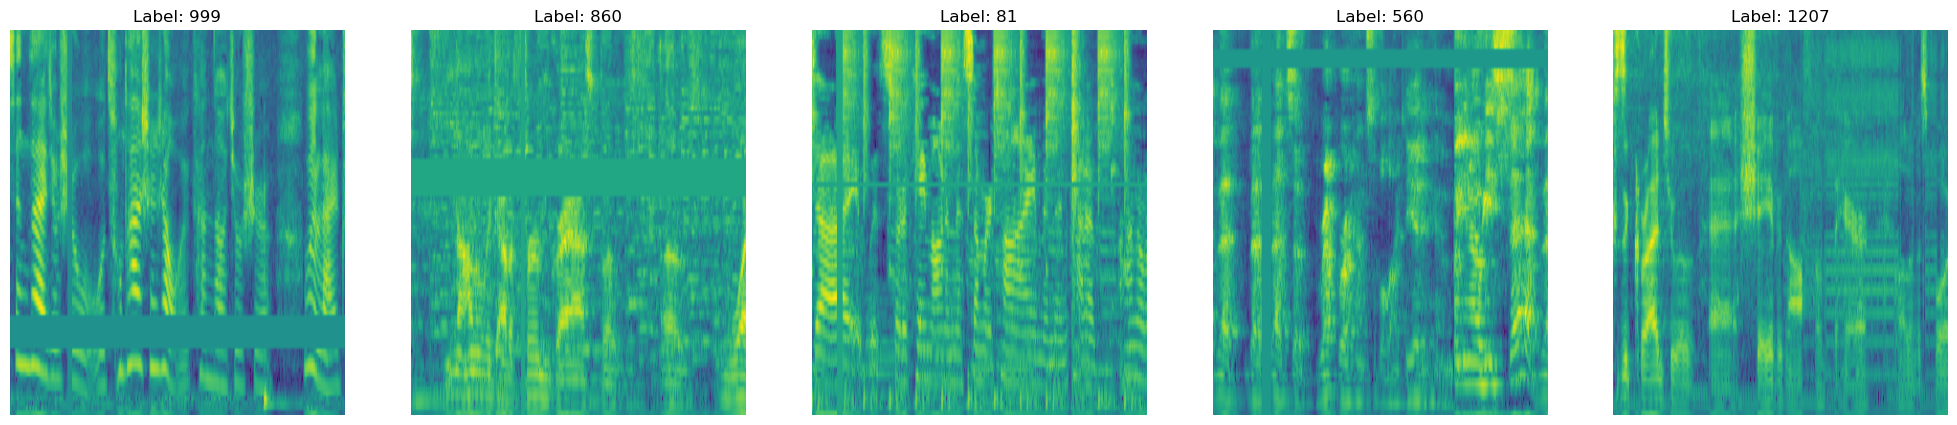

In [27]:
# Fonction pour tracer des spectrogrammes
def plot_spectrograms(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(25, 5))

    for i in range(num_images):
        # Sélectionner un segment aléatoire
        key = np.random.choice(list(dataset.segments.keys()))
        segment = dataset.segments[key]
        spkid = segment.spkid  # Récupérer le locuteur
        label = dataset.labels[spkid]  # Accéder au label via le spkid

        # Charger l'audio et extraire les FBANK
        audio, sample_rate = segment.load_audio()
        if dataset.audio_transforms:
            audio, sample_rate = dataset.audio_transforms(audio, sample_rate)
        feature = dataset.feature_extractor.extract(audio, sampling_rate=sample_rate)
        if dataset.feature_transforms:
            feature = dataset.feature_transforms(feature)

        # Vérification du type et de la forme du spectrogramme
        print(f"Spectrogram Type: {type(feature)}, Shape: {feature.shape}")

        # Transposer le spectrogramme pour avoir le temps en abscisse
        transposed_spectrogram = feature.numpy().T

        # Tracer le spectrogramme
        axes[i].imshow(transposed_spectrogram, aspect='auto', origin='lower', cmap='viridis')
        axes[i].set_title(f"Label: {label}")

        # Supprimer les axes
        axes[i].axis('off')

    plt.show()

# Tracer des spectrogrammes à partir du dataset d'entraînement
print("Train Dataset:")
plot_spectrograms(train_data, num_images=5)


# Training

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [30]:
#test au 22 janvier avec les module de effnet et adam et crossentropy
num_classes = len(set(training_data.labels.values()))
print(f"Nombre de classes pour le modèle : {num_classes}")
input_features = 81  # Caractéristiques des FBANKs
embed_features = 256  # Dimensions des embeddings

# Réinstanciation du modèle EfficientNetV2 avec tous ses modules
model = EfficientNetV2(
    num_classes=num_classes,
    input_features=input_features,
    embed_features=embed_features,
    model_name="efficientnet-b0"  # Utiliser EfficientNet-B0 comme base
)

# Définir la fonction de perte (CrossEntropyLoss pour simplifier)
#criterion = nn.CrossEntropyLoss()
criterion = JeffreysLoss(coeff1=0.1, coeff2=0.025)

# Utiliser Adam comme optimiseur pour tester la convergence
#optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=0.001)
optimizer = torch.optim.SGD(
    [{'params': model.parameters(), 'weight_decay': 1e-4, 'lr': 1e-3}], 
    momentum=0.9
)
# Scheduler pour réduire le learning rate
scheduler = IDRDScheduler(
    optimizer=optimizer,
    num_epochs=30,            # Durée de l'entraînement
    initial_lr=1e-3,          # Learning rate initial
    warm_up_epoch=1,          # Nombre d'époques pour le warm-up
    plateau_epoch=20,         # Époque à partir de laquelle la réduction commence
    patience=5,              # Nombre d'époques sans amélioration avant réduction
    factor=0.1,               # Facteur de réduction du learning rate
    amsmloss=0.3              # Hyperparamètre spécifique à AMSMLoss (facultatif ici)
)
# Déplacer le modèle sur le GPU
model = model.to(device)


Nombre de classes pour le modèle : 1251
Loaded pretrained weights for efficientnet-b0


### debug taille des modele avec torch.summary

In [34]:
from torchinfo import summary

from kiwano.model import ResNetV2

# Résumer la structure du modèle ResNetV2
resnet_input_shape = (1, 1, 350, 81)  # Taille d'entrée pour ResNetV2, ajustez si nécessaire
resnet_model = ResNetV2(input_features=81, embed_features=256, num_classes=6000)

summary(
    resnet_model,
    input_size=resnet_input_shape,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"],
)


Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
ResNetV2 (ResNetV2)                                     [1, 1, 350, 81]      [1, 256]             1,536,000            True
├─PreResNet (preresnet)                                 [1, 1, 350, 81]      [1, 2816, 44]        --                   True
│    └─Conv2d (pre_conv1)                               [1, 1, 350, 81]      [1, 128, 350, 81]    1,152                True
│    └─BatchNorm2d (pre_bn1)                            [1, 128, 350, 81]    [1, 128, 350, 81]    256                  True
│    └─SiLU (pre_activation1)                           [1, 128, 350, 81]    [1, 128, 350, 81]    --                   --
│    └─Sequential (layer1)                              [1, 128, 350, 81]    [1, 128, 350, 81]    --                   True
│    │    └─SEBasicBlock (0)                            [1, 128, 350, 81]    [1, 128, 350, 81]    328,448              True
│    

In [36]:
# Résumer la structure du modèle EfficientNetV2
efficientnet_input_shape = (1, 1, 350, 81)  # Taille d'entrée similaire à celle de ResNetV2


summary(
    model,
    input_size=efficientnet_input_shape,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"],
)


Layer (type (var_name))                                           Input Shape          Output Shape         Param #              Trainable
EfficientNetV2 (EfficientNetV2)                                   [1, 1, 350, 81]      [1, 256]             320,256              True
├─EfficientNet (base_model)                                       --                   --                   --                   True
│    └─Conv2d (_conv_stem)                                        [1, 1, 350, 81]      [1, 32, 174, 40]     288                  True
│    └─BatchNorm2d (_bn0)                                         [1, 32, 174, 40]     [1, 32, 174, 40]     64                   True
│    └─MemoryEfficientSwish (_swish)                              [1, 32, 174, 40]     [1, 32, 174, 40]     --                   --
│    └─ModuleList (_blocks)                                       --                   --                   --                   True
│    │    └─MBConvBlock (0)                                

# Training:

In [40]:
# Répertoire de sauvegarde
save_dir = "./saved_weights"
os.makedirs(save_dir, exist_ok=True)


In [41]:
# Fonction d'évaluation
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Evaluation', unit='batch'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs.unsqueeze(1))
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_acc = 100. * correct / total
    return test_acc

In [48]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30):
    best_acc = 0.0
    best_weights = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        model.output.set_m(scheduler.get_amsmloss())
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', unit='batch'):

            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs.unsqueeze(1), labels)  # Ajouter une dimension pour le channel
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        train_acc = 100. * correct / total
        print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.2f}%")

        # Évaluation sur le set de validation
        val_acc = evaluate(model, val_loader)
        print(f"Validation Accuracy: {val_acc:.2f}%")

        # Scheduler step
        scheduler.step()

        # Afficher le learning rate actuel pour chaque groupe de paramètres
        for i, param_group in enumerate(optimizer.param_groups):
            print(f"Learning rate for group {i}: {param_group['lr']}")

        
        # Sauvegarder le meilleur modèle
        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch + 1
            best_weights = model.state_dict()
            checkpoint = {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
            }
            torch.save(checkpoint, os.path.join(save_dir, f"model-effnet_epoch_{epoch + 1}.ckpt"))
            print(f"Meilleur modèle sauvegardé à l\'epoch {epoch + 1} avec une précision de {best_acc:.2f}%.")

    print(f"Meilleure précision obtenue : {best_acc:.2f}% à l\'epoch {best_epoch}")
    return best_weights


In [43]:
print(f"Nombre de batches dans val_loader : {len(val_loader)}")
print(f"Nombre de batches dans train_loader : {len(train_loader)}")


Nombre de batches dans val_loader : 480
Nombre de batches dans train_loader : 1919


In [49]:
checkpoint_path = "./saved_weights/model-effnet_epoch_10.ckpt"

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint.get("epoch", 0)

    # Recréer le scheduler avec un learning rate fixe
    scheduler = IDRDScheduler(optimizer, num_epochs=30, initial_lr=0.001, warm_up_epoch=5,
                              plateau_epoch=15, patience=10, factor=5, amsmloss=0.3)
    print(f"Checkpoint chargé, reprenant à l\'epoch {start_epoch}.")
else:
    print("Aucun checkpoint trouvé. Reprise de l'entraînement depuis le début.")
    start_epoch = 0


Aucun checkpoint trouvé. Reprise de l'entraînement depuis le début.


In [50]:
# Reprendre à l'époque 0 #train sans amsmloss et avec crossentropy effnetV2
start_epoch = 0

# Relancer l'entraînement
# Relancer l’entraînement
best_weights = train(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30)

Epoch 1/30: 100%|██████████| 1919/1919 [21:03<00:00,  1.52batch/s]


Train Loss: 6.5703 | Train Acc: 1.21%


Evaluation: 100%|██████████| 480/480 [01:39<00:00,  4.82batch/s]


Validation Accuracy: 0.07%
Learning rate for group 0: 1e-05
Meilleur modèle sauvegardé à l'epoch 1 avec une précision de 0.07%.


Epoch 2/30: 100%|██████████| 1919/1919 [20:17<00:00,  1.58batch/s]


...

Validation Accuracy: 0.07%
Learning rate for group 0: 0.09999999999999998


Epoch 30/30: 100%|██████████| 1919/1919 [21:07<00:00,  1.51batch/s]


Train Loss: 5.1809 | Train Acc: 13.30%


Evaluation: 100%|██████████| 480/480 [01:41<00:00,  4.72batch/s]

Validation Accuracy: 0.04%
Learning rate for group 0: 0.09999999999999998
Meilleure précision obtenue : 0.12% à l'epoch 3
